# [A6] Tree-Based Algorithms

In this notebook, a family of supervised learning methods that is especially strong on **tabular data** is introduced: single decision trees and ensemble methods built from many trees.

The aim of this assignment is to train and compare several tree-based classification models on the **Titanic** dataset:
1. `DecisionTreeClassifier` as an interpretable baseline
2. `RandomForestClassifier` as a bagging-based ensemble
3. `XGBClassifier` as a boosting-based ensemble

Tree-based models can capture non-linear relationships and feature interactions without manual feature engineering, and they usually do **not** require feature scaling.

At the same time, they still require careful handling of categorical variables, missing values, and model complexity.

## 1: Foundations

**The complete introduction of the theoretical basics is given in the lecture.**

Tree-based models recursively partition the feature space into smaller regions. Inside each region, the model predicts a single class label or probability. This makes them flexible, easy to visualize, and often surprisingly effective on structured datasets.

* **Decision Trees**: A flowchart-like model. At each node, the algorithm chooses a feature and a threshold that lead to the purest possible split. A deep tree can fit the training data extremely well, but it is also prone to overfitting.
* **Random Forest**: An ensemble learning method based on **bagging** (Bootstrap Aggregating). It trains many different trees on random subsets of the data and combines their predictions by voting. This mainly reduces variance and makes the model more stable.
* **XGBoost (Extreme Gradient Boosting)**: A boosting-based ensemble. Trees are built **sequentially**, and each new tree focuses more strongly on the mistakes of the previous ones. This often leads to excellent predictive performance on tabular data.
* **Feature Importance**: Tree-based models provide a simple notion of interpretability. They keep track of how much each feature reduces impurity across all splits, which allows us to estimate which inputs were most useful for the model.

## 2: About the Dataset and Exploratory Data Analysis (EDA)
The **Titanic** dataset contains passenger-level information such as ticket class, sex, age, fare, and family relations on board. The task is to predict whether a passenger **survived** (`1`) or **died** (`0`).

Before training any model, we should answer four basic questions:
1. How large is the dataset?
2. Is the target distribution balanced or imbalanced?
3. Which features already seem informative for survival?
4. Which columns contain missing values or seem unsuitable for direct modeling?

The following steps help us build this first intuition.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.max_columns = 50

titanic = pd.read_csv('../data/original_titanic.csv')
display(titanic.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Home-Dest
0,1,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,"St Louis, MO"
1,2,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON"
2,3,0,1,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON"
3,4,0,1,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON"
4,5,0,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON"


## 2.1: ✏️ Explore the dataset

In order to answer the posed questions above, get the following information about the dataset:
- its shape,
- the number of (non)survivors
- the percentage of (non)survivors 
- the number of missing values by column

Additionally, we're plotting the survival by gender and by class to see if there are any correlations.

Also, briefly interpret your observations of these numbers as comments

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Home-Dest
0,1,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,"St Louis, MO"
1,2,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON"
2,3,0,1,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON"
3,4,0,1,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON"
4,5,0,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON"


Shape: (1309, 13)
Wir haben insgesamt 1309 Passagiere in dem Datensatz

Survived counts:
Survived 500
Not Survived 809
Weniger als die Hälfte habe davon überlebt.

Survived relative frequencies:
survived freq: 0.382
 not survived freq: 0.618
Von den Frauen haben mehr überlbt wie von den Männern. Außerdem gibt es einen deutlich höhere Überlebensrate bei den Passagieren die in den besseren Klassen gereist sind.


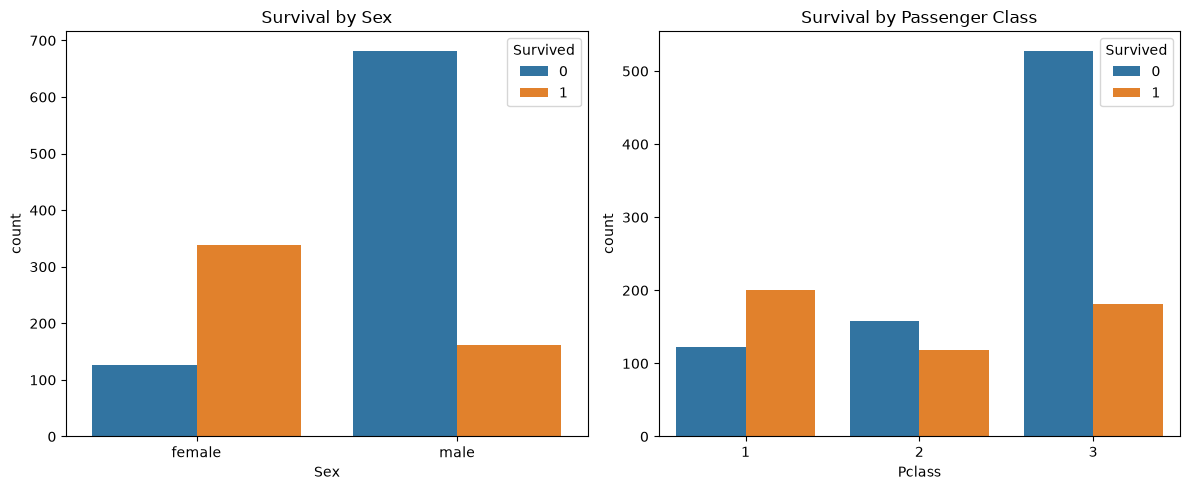


Missing values per column:


,count_NaN,dtype
Cabin,1014,str
Home-Dest,564,str
Age,263,float64
Embarked,2,str
Fare,1,float64
Sex,0,str
Name,0,str
Pclass,0,int64
Survived,0,int64
PassengerId,0,int64


Total Number of NaNs: 1844
Nicht von allen Passagieren ist die Boarding-Klasse und Start- bzw Reisezielort bekannt. Auch beim Alter gibt es ein paar Lücken


In [2]:
titanic_shape = []
survived_counts = []
survived_frequencies = []
missing_values = []

# TODO: Implement

display(titanic.head(5))
print('Shape:', titanic.shape)
print("Wir haben insgesamt 1309 Passagiere in dem Datensatz")
print('\nSurvived counts:')
survived_counts = np.sum(titanic[titanic["Survived"] == 1]["Survived"])
not_survived_counts = titanic[titanic["Survived"] == 0].shape[0]


print("Survived",survived_counts)
print("Not Survived",not_survived_counts)
print("Weniger als die Hälfte habe davon überlebt.")

print('\nSurvived relative frequencies:')
survived_frequ = round((survived_counts / titanic.shape[0]), 3)
not_survived_frequ = round((not_survived_counts / titanic.shape[0]), 3)
print(f"survived freq: {survived_frequ}\n not survived freq: {not_survived_frequ}")

print("Von den Frauen haben mehr überlbt wie von den Männern. Außerdem gibt es einen deutlich höhere Überlebensrate bei den Passagieren die in den besseren Klassen gereist sind.")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=titanic, x='Sex', hue='Survived')
plt.title('Survival by Sex')

plt.subplot(1, 2, 2)
sns.countplot(data=titanic, x='Pclass', hue='Survived')
plt.title('Survival by Passenger Class')

plt.tight_layout()
plt.show()

print('\nMissing values per column:')
nans = titanic.isna().sum().rename("count_NaN").sort_values(ascending=False)
dtypes = titanic.dtypes.rename("dtype")
display(nans.to_frame().join(dtypes))
print("Total Number of NaNs:", titanic.isna().sum().sum())
print("Nicht von allen Passagieren ist die Boarding-Klasse und Start- bzw Reisezielort bekannt. Auch beim Alter gibt es ein paar Lücken")

## 3: ✏️ Preprocessing
Tree-based models do **not** require feature scaling such as normalization or standardization. This is one of their major practical advantages compared to methods such as PCA, K-Means, or gradient-based neural networks.

However, the models still require a **numerical feature matrix** and a clean split into training and test data. In this exercise, we will:
1. **Drop unsuitable columns**: Identifiers and free-text-like columns such as `Name`, `Ticket`, `Cabin`, `PassengerId`, and `Home-Dest` are not used in this introductory example. 

In [3]:
df = titanic.copy()
columns_to_drop = ["Cabin", "Name", "Ticket", "Cabin", "PassengerId","Home-Dest"]

# TODO: Implement


df2 = df.drop(columns_to_drop, axis=1)

2. **Encode categorical variables**: `Sex` and `Embarked` will be transformed into numeric dummy columns using one-hot encoding. Create a new dataframe `df3` where the result is stored.

In [4]:
# TODO: Implement
one_hot_encode_cols = ["Sex", "Embarked"]
df3 = pd.get_dummies(df2, columns=one_hot_encode_cols)

df3

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,1,29.00,0,0,211.3375,True,False,False,False,True
1,1,1,0.92,1,2,151.5500,False,True,False,False,True
2,0,1,2.00,1,2,151.5500,True,False,False,False,True
3,0,1,30.00,1,2,151.5500,False,True,False,False,True
4,0,1,25.00,1,2,151.5500,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
1304,0,3,14.50,1,0,14.4542,True,False,True,False,False
1305,0,3,NaN,1,0,14.4542,True,False,True,False,False
1306,0,3,26.50,0,0,7.2250,False,True,True,False,False
1307,0,3,27.00,0,0,7.2250,False,True,True,False,False


3. **Create a train/test split**: Since `Survived` is not perfectly balanced, it is good practice to use `stratify=y` so that both subsets retain a similar class distribution. For the split, use `test_size=0.2` and `random_state=42` as additional parameters.

In [5]:
from sklearn.model_selection import train_test_split
y = df3["Survived"]
df4 = df3.drop(columns=["Survived"])

# TODO: Implement
X_train, X_test, y_train, y_test = train_test_split(
    df4, y, test_size=0.2, random_state=42, stratify=y
)




display(X_train.head())

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
999,3,NaN,0,0,7.7500,True,False,False,True,False
392,2,24.0,1,0,27.7208,True,False,True,False,False
628,3,11.0,4,2,31.2750,True,False,False,False,True
1165,3,25.0,0,0,7.2250,False,True,True,False,False
604,3,16.0,0,0,7.6500,True,False,False,False,True


## 4: ✏️ Dealing with Missing Values
After preprocessing, the largest missing-value problem is still the `Age` column. In addition, depending on the train/test split, there may also be isolated missing values in other numeric columns such as `Fare`.

The basic `DecisionTreeClassifier` and `RandomForestClassifier` implementations from scikit-learn cannot handle `NaN` values directly. Therefore, we need an imputation step before training these models.

To avoid **data leakage**, always fit the imputer only on the training set. Afterwards, apply the learned transformation to the test set.

For this exercise, median imputation is a sensible default because it is simple and fairly robust against outliers.

1. Identify all columns in X_train that still contain missing values

In [6]:
missing_cols = []
# TODO: Implement

nans = X_train.isna().any(axis=0)
missing_cols = X_train.columns[nans].tolist()

print('Missing columns:', list(missing_cols))

Missing columns: ['Age', 'Fare']


2. Create a SimpleImputer with strategy `median`, fit it on `X_train[missing_cols]` and then transform both splits.

In [7]:
from sklearn.impute import SimpleImputer

X_train_imputed = X_train.copy()
X_test_imputed = X_test.copy()
# TODO: Implement

imp_mean = SimpleImputer(missing_values=np.nan, strategy='median')
X_train_imputed.loc[:,missing_cols] = imp_mean.fit_transform(X_train[missing_cols])
X_test_imputed.loc[:,missing_cols] = imp_mean.transform(X_test[missing_cols])

3. Verify that the imputed training and test sets no longer contain missing values.

In [8]:
num_missing_vals_train = -1
num_missing_vals_test = -1

# TODO: Implement
num_missing_vals_train = X_train_imputed.isna().sum().sum()
num_missing_vals_test = X_test_imputed.isna().sum().sum()

print('Remaining missing values in X_train_imputed:', num_missing_vals_train)
print('Remaining missing values in X_test_imputed:', num_missing_vals_test)


Remaining missing values in X_train_imputed: 0
Remaining missing values in X_test_imputed: 0


## 5: ✏️ Implementing the Decision Tree Baseline
A single `DecisionTreeClassifier` is the simplest model in this family. It is highly interpretable because we can inspect the sequence of split rules directly.

At the same time, a deep tree can easily memorize the training data. To keep the model simple and reduce overfitting, we limit the depth via `max_depth=3`.

When evaluating the model, compare **training accuracy** and **test accuracy**. If the training accuracy is much higher than the test accuracy, this is a warning sign for overfitting.

1. Create and fit a `DecisionTreeClassifier` `dt_clf` with a maximum depth of `3` and initialize it in `random_state=42`.

In [9]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# TODO: Implement 
dt_clf = DecisionTreeClassifier(random_state=42, max_depth=3)


2. Predict on both X_train_imputed and X_test_imputed. Store the accuracies as `dt_train_acc` and `dt_test_acc`.

In [10]:
dt_train_acc = -1.0
dt_test_acc = -1.0

#TODO: Implement
dt_clf.fit(X_train_imputed, y_train)
train_pred = dt_clf.predict(X_train_imputed)
test_pred = dt_clf.predict(X_test_imputed)

dt_train_acc = accuracy_score(y_train, train_pred)
dt_test_acc = accuracy_score(y_test, test_pred)


print('Decision Tree Train Accuracy:', dt_train_acc)
print('Decision Tree Test Accuracy:', dt_test_acc)

Decision Tree Train Accuracy: 0.8118433619866284
Decision Tree Test Accuracy: 0.8358778625954199


3. Finally, we visualize the trained tree with `plot_tree`. Use the `columns` of our imputed train as `feature_names`.

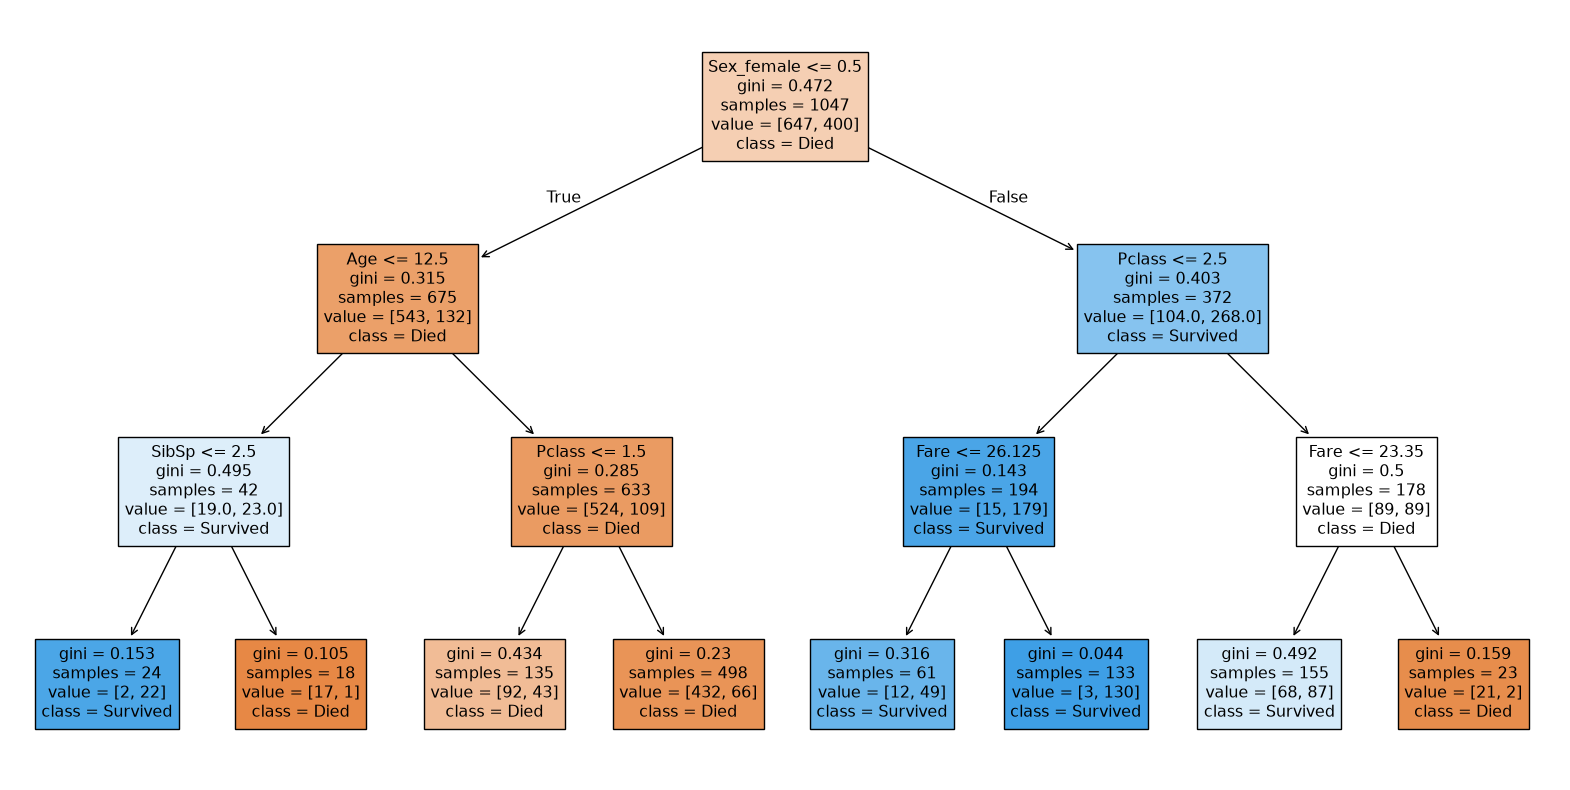

In [30]:
class_names = ['Died', 'Survived']

plt.figure(figsize=(20, 10))

# TODO: Implement
feature_names = X_train_imputed.columns

plot_tree(dt_clf, class_names=class_names, feature_names=feature_names, filled=True)

plt.show()

## 6:  Transitioning to Random Forests
A single decision tree is sensitive to noise and to small changes in the training data. A **Random Forest** reduces this instability by combining many trees that each see slightly different views of the data.

Two key ideas are used:
- **Bootstrap sampling**: every tree is trained on a random sample of the training data.
- **Random feature subsets**: at each split, only a subset of features is considered.

The final prediction is obtained by aggregating the predictions of all trees. In practice, this often improves generalization performance compared to a single tree.

However, even a Random Forest can overfit on a relatively small dataset if the individual trees are allowed to grow too deep. We therefore start with a slightly regularized forest and limit `max_depth`.

1. Create and train a `RandomForestClassifier` `rf_clf` with `100 estimators, a maximum depth of `5`and the same `random_state` as above. 

In [12]:
from sklearn.ensemble import RandomForestClassifier

# TODO: Implement
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_clf


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

2. Predict on both X_train_imputed and X_test_imputed. Store the accuracies as `rf_train_acc` and `rf_test_acc`.

In [13]:
rf_train_acc = -1.0
rf_test_acc = -1.0

# TODO: Implement
rf_clf.fit(X_train_imputed, y_train)

rf_train_pred = rf_clf.predict(X_train_imputed)
rf_test_pred = rf_clf.predict(X_test_imputed)

rf_train_acc = accuracy_score(rf_train_pred, y_train)
rf_test_acc = accuracy_score(rf_test_pred, y_test)

print('Random Forest Train Accuracy:', rf_train_acc)
print('Random Forest Test Accuracy:', rf_test_acc)

Random Forest Train Accuracy: 0.828080229226361
Random Forest Test Accuracy: 0.8435114503816794


In [ ]:
# TODO: Compare the result to the single Decision Tree in a short comment.
"""
Wir beobachten einen leicht besseren Score bei den Trainingsdaten bei Random Forest als bei
Decision Tree
Bei der Accuracy von den Test Daten liegen beide ungefähr gleich
"""

'\nWir beobachten einen leicht besseren Score bei den Trainingsdaten bei Random Forest (0.826) als bei\nDecision Tree (0.811)\nBei der Accuracy von den Test Daten liegen beide ungefähr gleich bei: 0.835\n'

## 7: ✏️ Pushing Limits with XGBoost
Boosting follows a different idea than bagging: instead of building many independent trees in parallel, the model is improved **sequentially**. Each new tree focuses more strongly on the mistakes that the current ensemble still makes.

`XGBoost` is one of the most successful boosting implementations for structured tabular data.

**Special feature**: XGBoost can handle missing values (`NaN`) internally. It learns a default direction for missing values during training. This means we can train it directly on the original `X_train` and `X_test` splits without applying the imputer from Section 4.

At the same time, boosted trees can also overfit if the trees are too deep or if the updates are too aggressive. We therefore start with a slightly more regularized configuration using shallow trees and a smaller learning rate.

1. Train an `xgb.XGBClassifier` `xgb_clf` on the original `X_train` and `y_train`. Use the following parameters: random_state=42, eval_metric='logloss', n_estimators=150, max_depth=2, learning_rate=0.05, reg_lambda=3.

In [15]:
import xgboost as xgb

# TODO: Implement 
xgb_clf = xgb.XGBClassifier(random_state=42, eval_metric='logloss', n_estimators=150, max_depth=2, learning_rate=0.05, reg_lambda=3)


2. Predict on both `X_train` and `X_test`. Store the accuracies as `xgb_train_acc` and `xgb_test_acc`.


In [16]:
xgb_train_acc = -1.0
xgb_test_acc = -1.0

# TODO: Implement
xgb_clf.fit(X_train, y_train)

xgb_train_pred = xgb_clf.predict(X_train)
xgb_test_pred = xgb_clf.predict(X_test)

xgb_train_acc = accuracy_score(y_train,xgb_train_pred)
xgb_test_acc = accuracy_score(y_test,xgb_test_pred)

print('XGBoost Train Accuracy:', xgb_train_acc)
print('XGBoost Test Accuracy:', xgb_test_acc)

# TODO: Compare the result to the Decision Tree and Random Forest.
"""
Ein bisschen bessere Performance auf dem Trainingsset, aber sehr ähnlich gute
Accuracy
"""


XGBoost Train Accuracy: 0.8223495702005731
XGBoost Test Accuracy: 0.8206106870229007


'\nEin bisschen bessere Performance auf dem Trainingsset, aber sehr ähnlich gute\nAccuracy\n'

## 8: Model Optimization (Hyperparameter Tuning)
So far, we selected model hyperparameters manually. In practice, we usually tune them **systematically** on the training data using cross-validation.

`GridSearchCV` evaluates several parameter combinations and estimates which setting generalizes best. The test set should remain untouched until the very end, because it is supposed to simulate truly unseen data.

For runtime reasons, we will use only a small parameter grid.

Note that the model with the best cross-validation score does not have to achieve the very best result on every single held-out split. Still, it is a much more systematic strategy than selecting parameters only by intuition.

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 3, 5, 10],
}


✏️ Create a `grid_search` for `RandomForestClassifier(random_state=42)`. Use `cv=5` and `n_jobs=-1`.

In [18]:
# TODO: Implement
rf_clf_2 = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
clf_grid = GridSearchCV(rf_clf_2, param_grid, cv=5, n_jobs=-1)



✏️ Fit the grid search on `X_train_imputed` and `y_train` and extract the best estimator into `best_rf`. Then use this estimator to predict on both `X_train_imputed` and `X_test_imputed` and store the resulting accuracies in `tuned_rf_train_acc` and `tuned_rf_test_acc`.

In [19]:
tuned_rf_train_acc = -1.0
tuned_rf_test_acc = -1.0

# TODO: Implement
clf_grid.fit(X_train_imputed, y_train)
best_rf = clf_grid.best_estimator_

clf_train_pred = best_rf.predict(X_train_imputed)
clf_test_pred = best_rf.predict(X_test_imputed)


tuned_rf_train_acc = accuracy_score(y_train, clf_train_pred) 
tuned_rf_test_acc = accuracy_score(y_test, clf_test_pred) 


print('Best RF Parameters:', clf_grid.best_params_)
print('Tuned RF Train Accuracy:', tuned_rf_train_acc)
print('Tuned RF Test Accuracy:', tuned_rf_test_acc)


Best RF Parameters: {'max_depth': 5, 'n_estimators': 200}
Tuned RF Train Accuracy: 0.833810888252149
Tuned RF Test Accuracy: 0.8396946564885496


## 9: Extracting Feature Importance
A major advantage of tree-based models is that they provide a rough ranking of how useful each feature was when building the split rules.

This helps us answer questions such as: Was `Sex` more important than `Pclass`? Did `Age` and `Fare` matter strongly?

Use the tuned Random Forest from Section 8 if available; otherwise, fall back to the untuned forest.

Note that feature importance is **model-specific** and should be interpreted as a heuristic, not as a causal explanation.

In [20]:
# TODO: Choose the model whose importances you want to inspect, e.g. best_rf or rf_clf.
model_for_importance = best_rf


✏️ Extract the feature importances and combine them with the feature names in a DataFrame `fi_df`. Then sort the importances in descending order from most important to least important.

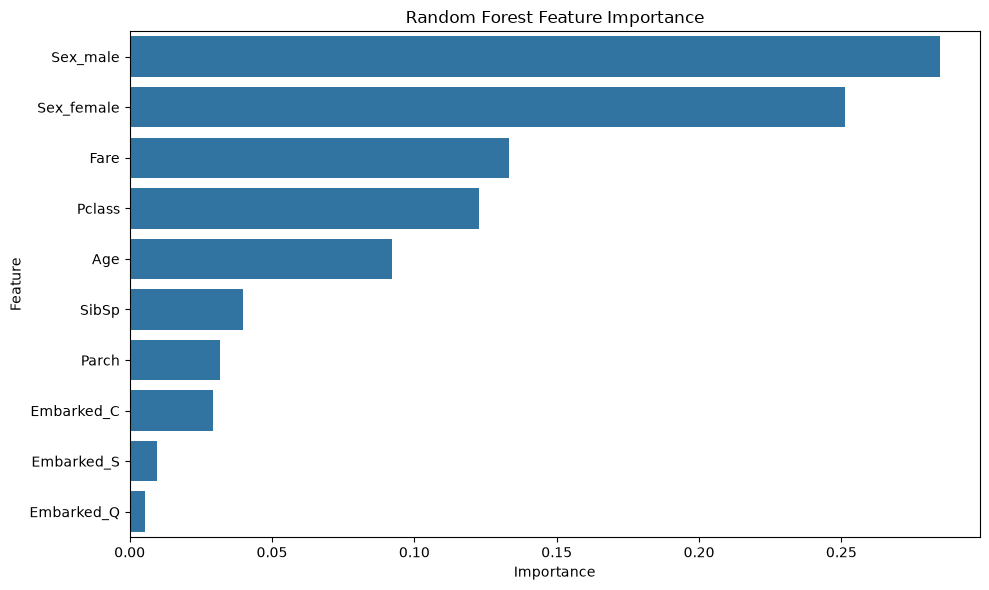

,Feature,Importance
6,Sex_male,0.284451
5,Sex_female,0.251410
4,Fare,0.133102
0,Pclass,0.122597
1,Age,0.092215
2,SibSp,0.039817
3,Parch,0.031884
7,Embarked_C,0.029306
9,Embarked_S,0.009774
8,Embarked_Q,0.005445


In [21]:
importances = []
feature_names = []

# TODO: Implement
importances = model_for_importance.feature_importances_
feature_names = model_for_importance.feature_names_in_
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# TODO: Sort here
fi_df = fi_df.sort_values(by=["Importance"], ascending=False)
#print(fi_df)


plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df, x='Importance', y='Feature')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

display(fi_df.head(10))

In [22]:
# ✏️ TODO: Which 3 features appear most important? Answer as comment.
"""
Die 3 wichtigsten Features sind Geschlecht, Ticketpreis und Pclass, die darüber aussagen ob ein Passagier überlebt oder nicht.
"""


'\nDie 3 wichtigsten Features sind Geschlecht, Ticketpreis und Pclass, die darüber aussagen ob ein Passagier überlebt oder nicht.\n'

## 10: Model Comparison and Reflection
To conclude the exercise, summarize the predictive performance of the different tree-based models and reflect on the trade-off between **accuracy** and **interpretability**.

1. Create a small summary table with the test accuracies of the Decision Tree, Random Forest, XGBoost, and tuned Random Forest.
2. Which model performs best on this split?
3. Which model would you choose if interpretability matters more than maximum accuracy?
4. Why do tree-based models usually not require feature scaling, while methods such as K-Means or PCA usually do?

When interpreting your results, remember that a single train/test split can differ from the more general trend described in the theory.

In [23]:
results = pd.DataFrame(
    {
        'Model': [
            'Decision Tree',
            'Random Forest',
            'XGBoost',
            'Tuned Random Forest',
        ],
        'Train Accuracy': [
            dt_train_acc,
            rf_train_acc,
            xgb_train_acc,
            tuned_rf_train_acc,
        ],
        'Test Accuracy': [
            dt_test_acc,
            rf_test_acc,
            xgb_test_acc,
            tuned_rf_test_acc,
        ],
    }
).sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)

display(results)

,Model,Train Accuracy,Test Accuracy
0,Random Forest,0.828080,0.843511
1,Tuned Random Forest,0.833811,0.839695
2,Decision Tree,0.811843,0.835878
3,XGBoost,0.822350,0.820611


In [ ]:
# ✏️ TODO: Answer questions 2-4 above as comments.
"""
2. von allen Modellen performt Random Forest am Besten (auf dem Testset)
3. Desicion Trees sind am besten Interprtierbar, da sie auf ein und dem selben Datensatz
    trainiert werden. Nicht wie bei z.B. Random Forsest, welcher auf
    unterschiedliche Subsets trainiert. Allerding haben Decision Trees nicht die
    selbe Accuracy wie z.B. Random Forest
4. Methoden wie K-means und PCA setzen den Fokus auf die Ähnlichkeit, bzw Distanz von allen Datenpunkten.
    Wo hingegen bei Tree-base Modell die Quantität der Daten betrachten wird. 
    Ähnlichkeit muss mit den anderen Features vergleichbar sein, das Problem haben wir bei Tree-based Modellen nicht
"""


'\n2. von allen Modellen performen Decision Tree und Random Forest gleich gut\n3. Es können alle Tree-based Modelle gleich gut interpretiert werden. Jediglich die Art wie die\n    Bäume trainiert werden unterscheidet sich.\n4. Methoden wie K-means und PCA setzen den Fokus auf die Ähnlichkeit, bzw Distanz von allen Datenpunkten.\n    Wo hingegen bei Tree-base Modell die Quantität der Daten betrachten wird. \n    Ähnlichkeit muss mit den anderen Features vergleichbar sein, das Problem haben wir bei Tree-based Modellen nicht\n'

## 11: Beyond Accuracy - Confusion Matrix
Accuracy gives only an overall summary of correct predictions. A **confusion matrix** gives more detailed information by separating the predictions into:
- **True Negatives (TN)**: predicted `Died`, actually `Died`
- **False Positives (FP)**: predicted `Survived`, actually `Died`
- **False Negatives (FN)**: predicted `Died`, actually `Survived`
- **True Positives (TP)**: predicted `Survived`, actually `Survived`

Use the model that performed best in Section 10 and inspect which type of error it makes more often.

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# TODO: Choose the model you want to evaluate, e.g. rf_clf, best_rf, or xgb_clf.
model_for_confusion = rf_clf


✏️ Create predictions on the corresponding test set. _Hint: `rf_clf` and `best_rf` use `X_test_imputed`, while `xgb_clf` uses `X_test`._

In [26]:
cm_lables = []
y_pred_confusion = []

# TODO: Implement:
y_pred_confusion = rf_test_pred
y_true_confusion = y_test
cm_lables = model_for_confusion.classes_

conf_matrix = confusion_matrix(y_true_confusion, y_pred_confusion, labels=cm_lables)

✏️ Plot the confusion matrix with class labels `['Died', 'Survived']`.

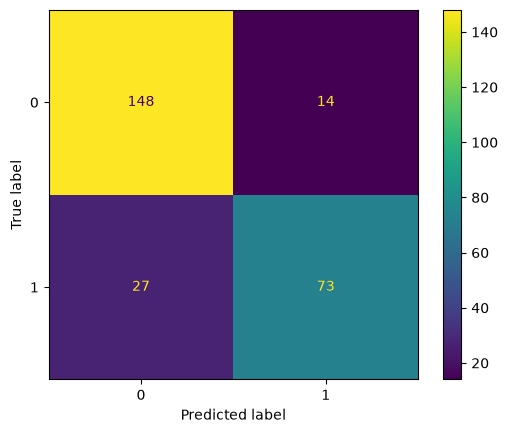

In [27]:
# TODO: Implement
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,display_labels=cm_lables)
disp.plot()
plt.show()



✏️ Print the raw confusion matrix values - which error type occurs more often: false positives or false negatives? Answer as comment.

In [ ]:
# TODO: Implement
print(conf_matrix)

# Der größte Fehlerfall ist False Negative (27), bedeutet das Model sagt
# Passagier gestorben (0) jedoch hat er eigentlich überlebt (1)


[[148  14]
 [ 27  73]]


## 12: ✏️ Bagging vs. Boosting in Practice
The Random Forest and XGBoost models are both ensembles of trees, but they combine these trees in different ways.

Answer the following questions:
1. Which model is based on **bagging**, and which one is based on **boosting**?
2. Are the trees trained independently or sequentially?
3. Which approach mainly aims to reduce variance, and which one mainly tries to correct previous errors?
4. Looking at your results from Sections 6-11, what practical conclusion would you draw for this Titanic task?

In [ ]:
"""
1. Xgboost = boosting
    Random Forset = Bagging

2. Xgboost trainiert sequenziell, während Random Forses parallel trainiert

3. Random Forest versucht die Varianz zu reduzieren mit der
    Auswahl zufälliger Trainings-Subsets
    Xgboost versucht vergangene Fehler zu korrigieren
4. Tree-base Modell bieten eine gute Erklärbarkeit zu der Voraussage
    von den Modellen. Es macht einen Unterschied zu welcher Unterart
    von Tree-based Modellen man greift. 
"""


'\n1. Xgboost = boosting\n    Random Forset = Bagging\n\n2. Xgboost trainiert sequenziell, während Random Forses parallel trainiert\n\n3. Random Forest versucht die Varianz zu reduzieren mit der\n    Auswahl zufälliger Trainings-Subsets\n    Xgboost versucht vergangene Fehler zu korrigieren\n4. Tree-base Modell bieten eine gute Erklärbarkeit zu der Voraussage\n    von den Modellen. Es macht einen Unterschied zu welcher Unterart\n    von diesen Modellen \n'